In [ ]:
# Install required packages (run once)
!pip install -q earthengine-api geemap contextily matplotlib-scalebar
!pip install contextily
!pip install rasterio
!pip install geopandas
!pip install earthengine-api geemap
!pip install python-dotenv


In [6]:


# Standard library
import sys
from pathlib import Path

# Add ../src relative to the notebook location
sys.path.append('../src')

# Earth Engine / geospatial
import ee
import eemont
import geemap
import geopandas as gpd
import rioxarray as rxr
import xarray as xr
import xee

# Plotting
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Widgets / notebook display
import ipywidgets as widgets
from IPython.display import clear_output, display

# Autoreload
%reload_ext autoreload
%autoreload 2

# Local imports
from utils.paths import gaul_path
from gee_helpers import authenticate_ee, get_utm_crs, request_gee_image


In [7]:
# Authenticate (browser pop-up on first run)
ee.Authenticate()

True

In [9]:
# =========================================================
# 1. IMPORTS AND INITIALIZATION
# =========================================================
import ee
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets

from IPython.display import display, clear_output

ee.Initialize()

In [11]:
kenya_regions = (
    ee.FeatureCollection('FAO/GAUL/2015/level1')
    .filter(ee.Filter.eq('ADM0_NAME', 'Kenya'))
)

nairobi           = kenya_regions.filter(ee.Filter.stringContains('ADM1_NAME', 'Nairobi'))
analysis_boundary = nairobi.geometry()

print("Nairobi County boundary loaded.")


Nairobi County boundary loaded.


In [12]:
start_date = '2024-01-01'
end_date   = '2024-12-31'

In [13]:
dynamic_urban = (
    ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")
    .select('label')
    .filterDate(start_date, end_date)
    .filterBounds(analysis_boundary)
    .filter(
        ee.Filter.Or(
            ee.Filter.calendarRange(1, 2, 'month'),   # Jan–Feb dry season
            ee.Filter.calendarRange(6, 8, 'month')    # Jun–Aug dry season
        )
    )
    .mode()
    .eq(6)
)

print("Urban/built pixel mask created (Dynamic World class 6).")


Urban/built pixel mask created (Dynamic World class 6).


In [14]:
landsat8_raw = (
    ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
    .select('ST_B10')
    .filterBounds(analysis_boundary)
    .filterDate(start_date, end_date)
    .filter(ee.Filter.lt('CLOUD_COVER', 10))
)

print('Landsat 8 collection size (cloud cover < 10 %):', landsat8_raw.size().getInfo())


Landsat 8 collection size (cloud cover < 10 %): 1


In [15]:
def scale_to_kelvin(image):
    lst_kelvin = (
        image
        .multiply(0.00341802)
        .add(149.0)
        .rename('LST_Kelvin')
    )
    return lst_kelvin.copyProperties(image, image.propertyNames())

landsat_thermal = (
    ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
    .select('ST_B10')
    .filterBounds(analysis_boundary)
    .filterDate(start_date, end_date)
    .filter(ee.Filter.lt('CLOUD_COVER', 10))
    .map(scale_to_kelvin)
)

print("Scaled collection size:", landsat_thermal.size().getInfo())


Scaled collection size: 1


In [ ]:
median_thermal         = landsat_thermal.median()
median_thermal_celsius = median_thermal.subtract(273.15).rename('LST_Celsius')

print("Median composite computed.")
print("  Kelvin  band name:", median_thermal.bandNames().getInfo())
print("  Celsius band name:", median_thermal_celsius.bandNames().getInfo())


Median composite computed.
  Kelvin  band name: ['LST_Kelvin']
  Celsius band name: ['LST_Celsius']


In [18]:
mean_lst_k = ee.Number(
    median_thermal.reduceRegion(
        reducer   = ee.Reducer.mean(),
        geometry  = analysis_boundary,
        scale     = 100,
        maxPixels = int(1e13)
    ).values().get(0)
)

mean_lst_c = mean_lst_k.subtract(273.15)

print(f"Mean LST — Kelvin:  {mean_lst_k.getInfo():.4f} K")
print(f"Mean LST — Celsius: {mean_lst_c.getInfo():.4f} °C")


Mean LST — Kelvin:  310.1061 K
Mean LST — Celsius: 36.9561 °C


In [19]:
uhi_index = median_thermal.expression(
    '(TIR - MEAN) / MEAN',
    {
        'TIR' : median_thermal,
        'MEAN': mean_lst_k
    }
).rename('UHI_Index')

# Inspect actual value range to verify threshold choices
uhi_range = uhi_index.reduceRegion(
    reducer   = ee.Reducer.minMax(),
    geometry  = analysis_boundary,
    scale     = 100,
    maxPixels = int(1e13)
).getInfo()

print("UHI Index value range:")
print(f"  Min: {uhi_range.get('UHI_Index_min', 'N/A'):.6f}")
print(f"  Max: {uhi_range.get('UHI_Index_max', 'N/A'):.6f}")


UHI Index value range:
  Min: -0.087233
  Max: 0.048835


In [20]:
uhi_index = median_thermal.expression(
    '(TIR - MEAN) / MEAN',
    {
        'TIR' : median_thermal,
        'MEAN': mean_lst_k
    }
).rename('UHI_Index')

# Inspect actual value range to verify threshold choices
uhi_range = uhi_index.reduceRegion(
    reducer   = ee.Reducer.minMax(),
    geometry  = analysis_boundary,
    scale     = 100,
    maxPixels = int(1e13)
).getInfo()

print("UHI Index value range:")
print(f"  Min: {uhi_range.get('UHI_Index_min', 'N/A'):.6f}")
print(f"  Max: {uhi_range.get('UHI_Index_max', 'N/A'):.6f}")


UHI Index value range:
  Min: -0.087233
  Max: 0.048835


In [21]:
uhi_positive = uhi_index.gte(0)   # Only classify pixels warmer than mean

uhi_classes = (
    ee.Image.constant(0).byte()
    .where(uhi_index.gte(0.000).And(uhi_index.lt(0.005)), 1)   # Mild
    .where(uhi_index.gte(0.005).And(uhi_index.lt(0.010)), 2)   # Moderate
    .where(uhi_index.gte(0.010).And(uhi_index.lt(0.015)), 3)   # Strong
    .where(uhi_index.gte(0.015).And(uhi_index.lt(0.020)), 4)   # Very Strong
    .where(uhi_index.gte(0.020), 5)                             # Extreme
    .updateMask(dynamic_urban)    # Restrict to built-up areas only
    .updateMask(uhi_positive)     # Exclude cool pixels (negative UHI index)
)

print("UHI classification complete.")


UHI classification complete.


In [22]:
world_pop = (
    ee.ImageCollection("WorldPop/GP/100m/pop")
    .filter(ee.Filter.eq('country', 'KEN'))
    .filterDate('2020-01-01', '2020-12-31')
    .first()
    .clip(analysis_boundary)
)

print("WorldPop 2020 image loaded.")


WorldPop 2020 image loaded.


In [23]:
high_heat_mask  = uhi_classes.gte(4)
vulnerable_pop  = world_pop.updateMask(high_heat_mask)

total_vulnerable = vulnerable_pop.reduceRegion(
    reducer   = ee.Reducer.sum(),
    geometry  = analysis_boundary,
    scale     = 100,
    maxPixels = int(1e13)
).getInfo()

print("Population in High UHI Zones (class ≥ 4):")
print(f"  {list(total_vulnerable.values())[0]:,.0f} people")


Population in High UHI Zones (class ≥ 4):
  1,948,966 people


In [24]:
import pandas as pd

pop_uhi = world_pop.addBands(uhi_classes)

pop_by_class = pop_uhi.reduceRegion(
    reducer = ee.Reducer.sum().group(
        groupField = 1,
        groupName  = 'UHI_Class'
    ),
    geometry  = analysis_boundary,
    scale     = 100,
    maxPixels = int(1e13)
).getInfo()

groups = pop_by_class.get('groups', [])
df_pop = pd.DataFrame([
    {'UHI_Class': g['UHI_Class'], 'Population': g['sum']}
    for g in groups
]).sort_values('UHI_Class').reset_index(drop=True)

label_map = {1: 'Mild', 2: 'Moderate', 3: 'Strong', 4: 'Very Strong', 5: 'Extreme'}
df_pop['Intensity'] = df_pop['UHI_Class'].map(label_map)
df_pop['Population'] = df_pop['Population'].round(0).astype(int)

print("=== Population by UHI Class ===")
display(df_pop[['UHI_Class', 'Intensity', 'Population']])


=== Population by UHI Class ===


,UHI_Class,Intensity,Population
0,1,Mild,197691
1,2,Moderate,331401
2,3,Strong,551150
3,4,Very Strong,807147
4,5,Extreme,1141819


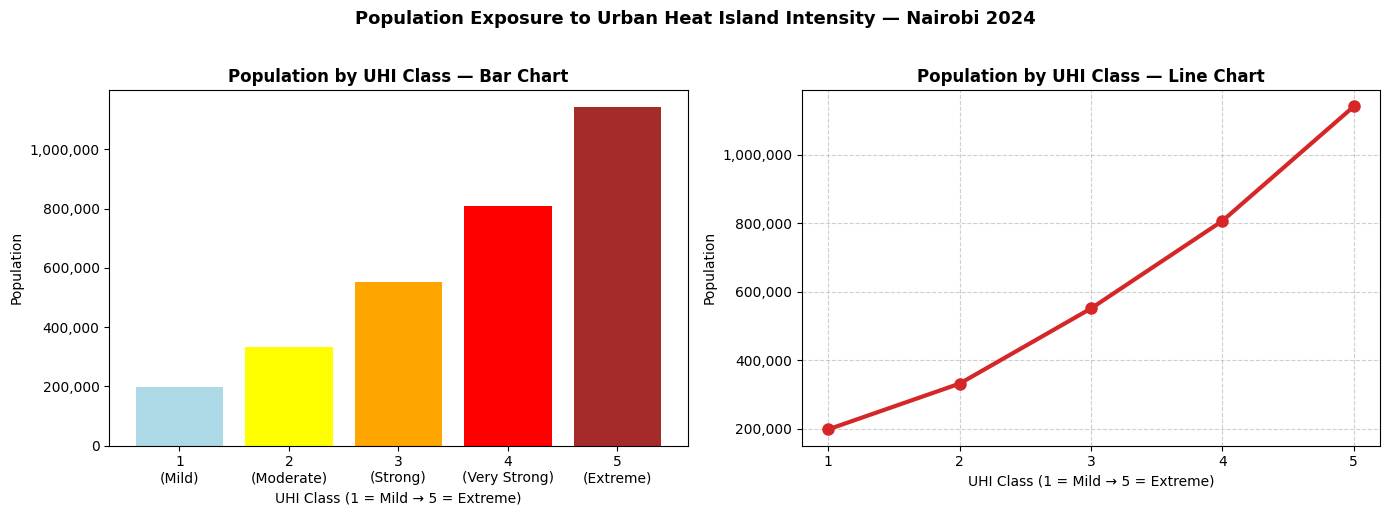

Chart saved as uhi_population_chart.png


In [32]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

colors = ['#add8e6', '#ffff00', '#ffa500', '#ff0000','#a52a2a',]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Column chart
axes[0].bar(df_pop['UHI_Class'], df_pop['Population'], color=colors[:len(df_pop)])
axes[0].set_title('Population by UHI Class — Bar Chart', fontweight='bold')
axes[0].set_xlabel('UHI Class (1 = Mild → 5 = Extreme)')
axes[0].set_ylabel('Population')
axes[0].set_xticks(df_pop['UHI_Class'])
axes[0].set_xticklabels([f"{r['UHI_Class']}\n({r['Intensity']})" for _, r in df_pop.iterrows()])
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Line chart
axes[1].plot(df_pop['UHI_Class'], df_pop['Population'],
             marker='o', linewidth=3, markersize=8, color='#d62728')
axes[1].set_title('Population by UHI Class — Line Chart', fontweight='bold')
axes[1].set_xlabel('UHI Class (1 = Mild → 5 = Extreme)')
axes[1].set_ylabel('Population')
axes[1].set_xticks(df_pop['UHI_Class'])
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Population Exposure to Urban Heat Island Intensity — Nairobi 2024',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
#plt.savefig('uhi_population_chart.png', dpi=150, bbox_inches='tight')
plt.savefig('/Users/adenkumary/Documents/Aden’s MacBook Pro /1.  PhD_ YR_2/6. AAG Abstract/11. UHI/data/output/uhi_population_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as uhi_population_chart.png")


In [26]:
high_heat = uhi_classes.gte(3)
low_heat  = uhi_classes.lt(3)

def pop_sum(mask):
    result = world_pop.updateMask(mask).reduceRegion(
        reducer   = ee.Reducer.sum(),
        geometry  = analysis_boundary,
        scale     = 100,
        maxPixels = int(1e13)
    ).getInfo()
    return list(result.values())[0]

high_pop  = pop_sum(high_heat)
low_pop   = pop_sum(low_heat)
total_pop = pop_sum(ee.Image.constant(1))   # no mask = full count

print(f"{'Category':<25} {'Population':>15}")
print("-" * 42)
print(f"{'High Heat (class ≥ 3)':<25} {high_pop:>15,.0f}")
print(f"{'Low Heat  (class < 3)':<25} {low_pop:>15,.0f}")
print(f"{'Total Population':<25} {total_pop:>15,.0f}")
print(f"\nHigh-heat share: {high_pop / total_pop * 100:.1f}%")


Category                       Population
------------------------------------------
High Heat (class ≥ 3)           2,500,116
Low Heat  (class < 3)             529,092
Total Population                4,148,561

High-heat share: 60.3%


In [27]:
import geemap

Map = geemap.Map()
Map.centerObject(analysis_boundary, 10)

Map.addLayer(analysis_boundary, {'color': 'yellow'}, 'Nairobi County Boundary')

Map.addLayer(
    dynamic_urban.clip(analysis_boundary),
    {'min': 0, 'max': 1, 'palette': ['white', 'grey']},
    'Urban Mask', False
)

Map.addLayer(
    median_thermal.clip(analysis_boundary),
    {'min': 295, 'max': 315, 'palette': ['blue', 'cyan', 'yellow', 'orange', 'red']},
    'Median LST (Kelvin)', False
)

Map.addLayer(
    median_thermal_celsius.clip(analysis_boundary),
    {'min': 22, 'max': 42, 'palette': ['blue', 'cyan', 'yellow', 'orange', 'red']},
    'Median LST (Celsius)', False
)

Map.addLayer(
    uhi_index.clip(analysis_boundary),
    {'min': -0.01, 'max': 0.025, 'palette': ['blue', 'cyan', 'yellow', 'orange', 'red']},
    'UHI Index (raw)', False
)

Map.addLayer(
    uhi_classes.clip(analysis_boundary),
    {'min': 1, 'max': 5, 'palette': ['lightblue', 'yellow', 'orange', 'brown', 'red']},
    'UHI Classes (Urban Only)', True
)

Map.addLayer(
    world_pop,
    {'min': 0, 'max': 500, 'palette': ['white', 'yellow', 'orange', 'red']},
    'WorldPop 2020', False
)

Map.addLayer(
    vulnerable_pop,
    {'min': 0, 'max': 500, 'palette': ['white', 'orange', 'red']},
    'Population in High UHI Zones', False
)

Map


Map(center=[-1.289955719076942, 36.86835227030284], controls=(WidgetControl(options=['position', 'transparent_…

In [29]:
export_base = dict(
    region    = analysis_boundary,
    scale     = 100,
    crs       = 'EPSG:4326',
    maxPixels = int(1e13),
    folder    = 'UrbanHeat'
)

# A) Vulnerable population raster
task_a = ee.batch.Export.image.toDrive(
    image       = vulnerable_pop,
    description = 'Population_High_UHI_Nairobi_2024',
    **export_base
)
task_a.start()
print("Task A — Vulnerable population raster:", task_a.status())

# B) UHI Classified Raster
task_b = ee.batch.Export.image.toDrive(
    image       = uhi_classes.clip(analysis_boundary),
    description = 'UHI_Classes_Nairobi_Landsat8_2024',
    **export_base
)
task_b.start()
print("Task B — UHI classes raster:", task_b.status())

# C) Raw UHI Index (urban pixels only)
task_c = ee.batch.Export.image.toDrive(
    image       = uhi_index.clip(analysis_boundary).updateMask(dynamic_urban),
    description = 'UHI_Index_Raw_Nairobi_Landsat8_2024',
    **export_base
)
task_c.start()
print("Task C — Raw UHI index raster:", task_c.status())


Task A — Vulnerable population raster: {'state': 'READY', 'description': 'Population_High_UHI_Nairobi_2024', 'priority': 100, 'creation_timestamp_ms': 1773871821707, 'update_timestamp_ms': 1773871821707, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': 'IH557V2SCNKG3EF4XKLHYL4T', 'name': 'projects/90378099004/operations/IH557V2SCNKG3EF4XKLHYL4T'}
Task B — UHI classes raster: {'state': 'READY', 'description': 'UHI_Classes_Nairobi_Landsat8_2024', 'priority': 100, 'creation_timestamp_ms': 1773871822339, 'update_timestamp_ms': 1773871822339, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': 'W62QNPKX6XRUNRBOKBTR53ZB', 'name': 'projects/90378099004/operations/W62QNPKX6XRUNRBOKBTR53ZB'}
Task C — Raw UHI index raster: {'state': 'READY', 'description': 'UHI_Index_Raw_Nairobi_Landsat8_2024', 'priority': 100, 'creation_timestamp_ms': 1773871822931, 'update_timestamp_ms': 1773871822931, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': 'G2UJXH3L3CM2NRHULDBBUXQK', 'n